# 1. Exploratory Data Analysis (EDA)

The purpose of this section is to understand the dataset before building machine learning models. We will examine the dataset structure, identify missing values and duplicates, analyze customer shopping behavior, and explore the distribution of important features and target variables.

---

### 1. İlkin Məlumat Təhlili (EDA)

Bu bölmənin məqsədi maşın öyrənməsi modellərini qurmazdan əvvəl verilənlər bazasını (dataseti) tam başa düşməkdir. Biz datasetin strukturunu nəzərdən keçirəcək, çatışmayan dəyərləri və təkrarlanmaları müəyyənləşdirəcək, müştərilərin alış-veriş davranışlarını analiz edəcək və vacib xüsusiyyətlərin həmçinin hədəf dəyişənlərinin paylanmasını araşdıracağıq.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv('train.csv')

In [5]:
df.head()

,customer_ID,shopping_pt,record_type,day,time,state,location,group_size,homeowner,car_age,car_value,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
0,10000000,1,0,0,08:35,IN,10001,2,0,2,g,3.0,46,42,1,1.0,2.0,1,0,2,2,1,2,2,633
1,10000000,2,0,0,08:38,IN,10001,2,0,2,g,3.0,46,42,1,1.0,2.0,1,0,2,2,1,2,1,630
2,10000000,3,0,0,08:38,IN,10001,2,0,2,g,3.0,46,42,1,1.0,2.0,1,0,2,2,1,2,1,630
3,10000000,4,0,0,08:39,IN,10001,2,0,2,g,3.0,46,42,1,1.0,2.0,1,0,2,2,1,2,1,630
4,10000000,5,0,0,11:55,IN,10001,2,0,2,g,3.0,46,42,1,1.0,2.0,1,0,2,2,1,2,1,630


### Observation

The dataset contains customer shopping history for insurance policies. Each row represents either a shopping point (quote evaluation) or a final purchase event. Features include customer demographics (age, marital status, location), vehicle details (car age, value), previous insurance history, the 7 coverage options (A-G), and the policy cost.

### Şərh / Müşahidə

Dataset müştərilərin sığorta paketləri üçün alış-veriş tarixçəsini ehtiva edir. Hər bir sətir ya bir shopping point-i (qiymət təklifinin qiymətləndirilməsini), ya da yekun satınalma hadisəsini ifadə edir. Sütunlara müştəri demoqrafiyası (yaş, ailə vəziyyəti, yerləşdiyi yer), avtomobil məlumatları (avtomobilin yaşı, dəyəri), əvvəlki sığorta tarixçəsi, 7 fərqli təminat seçimi (A-G) ve siyasət qiyməti (cost) daxildir.

In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 665249
Columns : 25


### Observation

The dataset consists of **665,249 rows** and **25 columns**. Given the large volume of data, it provides a solid foundation for training robust machine learning models.

### Şərh / Müşahidə

Dataset **665,249 sətir** və **25 sütundan** ibarətdir. Məlumatın həcminin bu dərəcədə böyük olması, dayanıqlı və dəqiq maşın öyrənməsi modellərinin öyrədilməsi üçün güclü bir zəmin yaradır.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665249 entries, 0 to 665248
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   customer_ID        665249 non-null  int64  
 1   shopping_pt        665249 non-null  int64  
 2   record_type        665249 non-null  int64  
 3   day                665249 non-null  int64  
 4   time               665249 non-null  object 
 5   state              665249 non-null  object 
 6   location           665249 non-null  int64  
 7   group_size         665249 non-null  int64  
 8   homeowner          665249 non-null  int64  
 9   car_age            665249 non-null  int64  
 10  car_value          663718 non-null  object 
 11  risk_factor        424831 non-null  float64
 12  age_oldest         665249 non-null  int64  
 13  age_youngest       665249 non-null  int64  
 14  married_couple     665249 non-null  int64  
 15  C_previous         646538 non-null  float64
 16  du

### Observation

Most features are numerical (`int64` or `float64`). However, categorical attributes like `time`, `state`, and `car_value` are identified as object data types. These will need proper encoding (e.g., Label Encoding or One-Hot Encoding) during the preprocessing phase.

### Şərh / Müşahidə

Xüsusiyyətlərin böyük hissəsi rəqəmsaldır (`int64` və ya `float64`). Bununla belə, `time`, `state` və `car_value` kimi kateqoriyal göstəricilər "object" data tipi olaraq müəyyən edilmişdir. Data preprocessing (ilkin emal) mərhələsində bu dəyişənlərə uyğun kodlaşdırma üsulları (məsələn, Label Encoding və ya One-Hot Encoding) tətbiq edilməlidir.

In [8]:
df.describe()

,customer_ID,shopping_pt,record_type,day,location,group_size,homeowner,car_age,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
count,6.652490e+05,665249.000000,665249.000000,665249.000000,665249.000000,665249.000000,665249.000000,665249.000000,424831.000000,665249.000000,665249.000000,665249.000000,646538.000000,646538.000000,665249.000000,665249.000000,665249.000000,665249.000000,665249.000000,665249.000000,665249.000000,665249.000000
mean,1.007655e+07,4.219966,0.145824,1.969429,12271.543022,1.234784,0.536229,8.139437,2.563996,44.992403,42.577588,0.209782,2.444718,6.003774,0.927546,0.454236,2.275265,2.454299,0.445193,1.162768,2.275120,635.785008
std,4.404978e+04,2.394369,0.352930,1.453470,1564.789415,0.461036,0.498686,5.764598,1.111584,17.403440,17.460432,0.407153,1.034596,4.680793,0.595221,0.497902,0.990798,0.753953,0.496987,0.943594,0.909567,45.993758
min,1.000000e+07,1.000000,0.000000,0.000000,10001.000000,1.000000,0.000000,0.000000,1.000000,18.000000,16.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,260.000000
25%,1.003852e+07,2.000000,0.000000,1.000000,10936.000000,1.000000,0.000000,3.000000,2.000000,28.000000,26.000000,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,605.000000
50%,1.007640e+07,4.000000,0.000000,2.000000,12027.000000,1.000000,1.000000,7.000000,3.000000,44.000000,40.000000,0.000000,3.000000,5.000000,1.000000,0.000000,2.000000,3.000000,0.000000,1.000000,2.000000,635.000000
75%,1.011470e+07,6.000000,0.000000,3.000000,13426.000000,1.000000,1.000000,12.000000,4.000000,60.000000,57.000000,0.000000,3.000000,9.000000,1.000000,1.000000,3.000000,3.000000,1.000000,2.000000,3.000000,665.000000
max,1.015272e+07,13.000000,1.000000,6.000000,16580.000000,4.000000,1.000000,85.000000,4.000000,75.000000,75.000000,1.000000,4.000000,15.000000,2.000000,1.000000,4.000000,3.000000,1.000000,3.000000,4.000000,922.000000


In [9]:
df.describe(include="object")

,time,state,car_value
count,665249,665249,663718
unique,1204,36,9
top,14:35,FL,e
freq,1553,106287,219251


In [10]:
missing = df.isna().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

risk_factor          240418
C_previous            18711
duration_previous     18711
car_value              1531
dtype: int64

In [11]:
missing_percent = df.isna().mean()*100

missing_percent = missing_percent[missing_percent>0]

missing_percent.sort_values(ascending=False)

risk_factor          36.139551
C_previous            2.812631
duration_previous     2.812631
car_value             0.230139
dtype: float64

### Observation

Missing data is present in four features:
- `risk_factor`: 240,418 missing values (~36.14%)
- `C_previous` & `duration_previous`: 18,711 missing values each (~2.81%)
- `car_value`: 1,531 missing values (~0.23%)

We will need imputation strategies (like median imputation or creating a separate 'Unknown' category) in the preprocessing stage to handle these gaps.

### Şərh / Müşahidə

Dörd fərqli xüsusiyyətdə ötürülmüş (missing) məlumatlar mövcuddur:
- `risk_factor`: 240,418 boş xana (~36.14%)
- `C_previous` və `duration_previous`: hər birində 18,711 boş xana (~2.81%)
- `car_value`: 1,531 boş xana (~0.23%)

Modelin düzgün işləməsi üçün preprocessing mərhələsində bu boşluqların doldurulması strategiyalarından (məsələn, median ilə doldurma və ya ayrıca 'Unknown' kateqoriyası yaratmaq) istifadə edəcəyik.

In [12]:
df.duplicated().sum()

np.int64(0)

### Observation

There are **0 duplicate rows** in the dataset. Every record represents a unique quote sequence or final transaction, ensuring no redundancy in the raw data.

### Şərh / Müşahidə

Datasetdə **0 təkrarlanan sətir** (duplicate) tapılmışdır. Hər bir qeyd unikal bir təklif ardıcıllığını və ya yekun əməliyyatı təmsil edir ki, bu da xam datada heç bir təkrarlanma və artıqlıq olmadığını göstərir.

In [13]:
print("Unique customers:", df["customer_ID"].nunique())

Unique customers: 97009


### Observation

There are **97,009 unique customers** in the dataset. Since the total row count is 665,249, this confirms that each customer appears multiple times, representing their sequential journey through different shopping points before making a purchase.

### Şərh / Müşahidə

Datasetdə **97,009 unikal müştəri** var. Ümumi sətir sayının 665,249 olduğunu nəzərə alsaq, bu, hər bir müştərinin sistemdə bir neçə dəfə göründüyünü təsdiqləyir. Bu da onların yekun alışı etməzdən əvvəl müxtəlif alış-veriş nöqtələrindən keçən ardıcıl addımlarını nümayiş etdirir.

In [14]:
df["record_type"].value_counts()

record_type
0    568240
1     97009
Name: count, dtype: int64

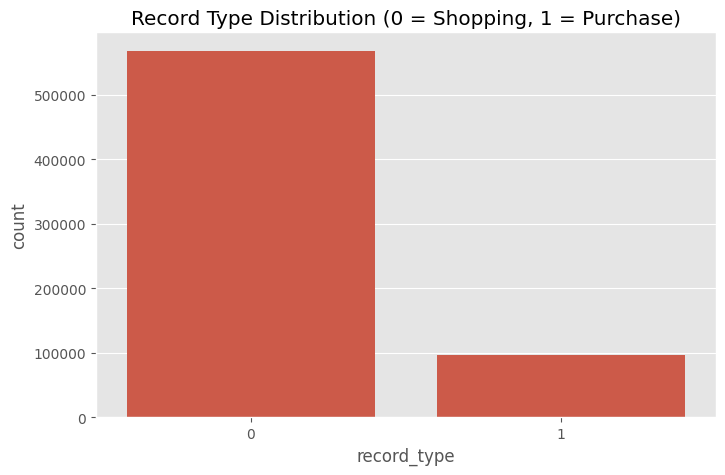

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="record_type")
plt.title("Record Type Distribution (0 = Shopping, 1 = Purchase)")
plt.show()

### Observation

The `record_type` distribution shows:
- **568,240 shopping records** (type 0)
- **97,009 purchase records** (type 1)

This matches the number of unique customers perfectly, meaning every customer has exactly one final purchase transaction record.

### Şərh / Müşahidə

`record_type` paylanması aşağıdakı nəticəni göstərir:
- **568,240 alış-veriş/təklif qeydi** (tip 0)
- **97,009 satınalma qeydi** (tip 1)

Bu rəqəm unikal müştərilərin sayı ilə tamamilə eynidir, yəni hər bir müştərinin datasetdə tam olaraq bir dənə yekun satınalma əməliyyatı qeydi mövcuddur.

In [16]:
shopping_counts = df.groupby("customer_ID").size()

In [17]:
shopping_counts.describe()

count    97009.000000
mean         6.857601
std          1.998357
min          3.000000
25%          5.000000
50%          7.000000
75%          8.000000
max         13.000000
dtype: float64

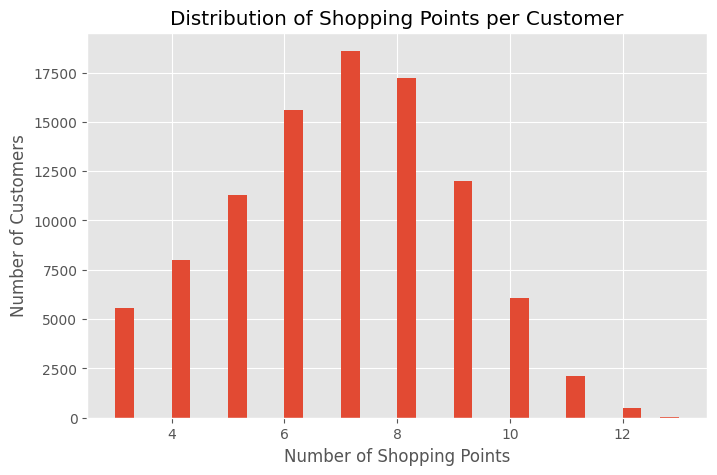

In [18]:
plt.figure(figsize=(8,5))

plt.hist(shopping_counts,bins=30)

plt.xlabel("Number of Shopping Points")

plt.ylabel("Number of Customers")

plt.title("Distribution of Shopping Points per Customer")

plt.show()

### Observation

On average, a customer requests **6.86 shopping points** (quotes) before making a final purchase. The minimum number of interactions is 3, while some customers compare up to 13 different variations. This highlights the dynamic decision-making behavior of customers.

### Şərh / Müşahidə

Orta hesabla, bir müştəri yekun alışı etməzdən əvvəl **6.86 shopping point** (qiymət təklifi) sorğulayır. Minimum qarşılıqlı əlaqə sayı 3-dür, bəzi müştərilər isə qərar verməzdən əvvəl 13 fərqli variasiyanı müqayisə edir. Bu, müştərilərin dinamik qərarvermə davranışını açıq şəkildə nümayiş etdirir.

In [19]:
targets = ["A", "B", "C", "D", "E", "F", "G"]
for col in targets:
    print(f"\nDistribution for Target {col} (at Purchase):")
    print(df[df['record_type'] == 1][col].value_counts().sort_index())


Distribution for Target A (at Purchase):
A
0    21378
1    59582
2    16049
Name: count, dtype: int64

Distribution for Target B (at Purchase):
B
0    50824
1    46185
Name: count, dtype: int64

Distribution for Target C (at Purchase):
C
1    28993
2    20393
3    37963
4     9660
Name: count, dtype: int64

Distribution for Target D (at Purchase):
D
1    12626
2    21676
3    62707
Name: count, dtype: int64

Distribution for Target E (at Purchase):
E
0    52132
1    44877
Name: count, dtype: int64

Distribution for Target F (at Purchase):
F
0    31246
1    23962
2    36169
3     5632
Name: count, dtype: int64

Distribution for Target G (at Purchase):
G
1    20257
2    37778
3    30697
4     8277
Name: count, dtype: int64


### Observation

The insurance package is composed of seven independent coverage options (**A** to **G**). Each option has a limited number of ordinal categories. Examining their distribution specifically at `record_type == 1` ensures we understand the actual target classes our model will need to predict. Since we have 7 targets, we will treat this as a Multi-Output Classification problem.

### Şərh / Müşahidə

Sığorta paketi yeddi müstəqil təminat seçimindən (**A**-dan **G**-yə qədər) ibarətdir. Hər bir seçimin məhdud sayda sıralı kateqoriyası var. Bu paylanmanı xüsusilə `record_type == 1` (satınalma) anında araşdırmaq modelimizin proqnozlaşdırmalı olduğu real hədəf siniflərini anlamağa kömək edir. Eyni anda 7 fərqli hədəfi təxmin etməli olduğumuz üçün, bu problemi "Multi-Output Classification" (Çox-Çıxışlı Təsnifat) problemi kimi ələ alacağıq.

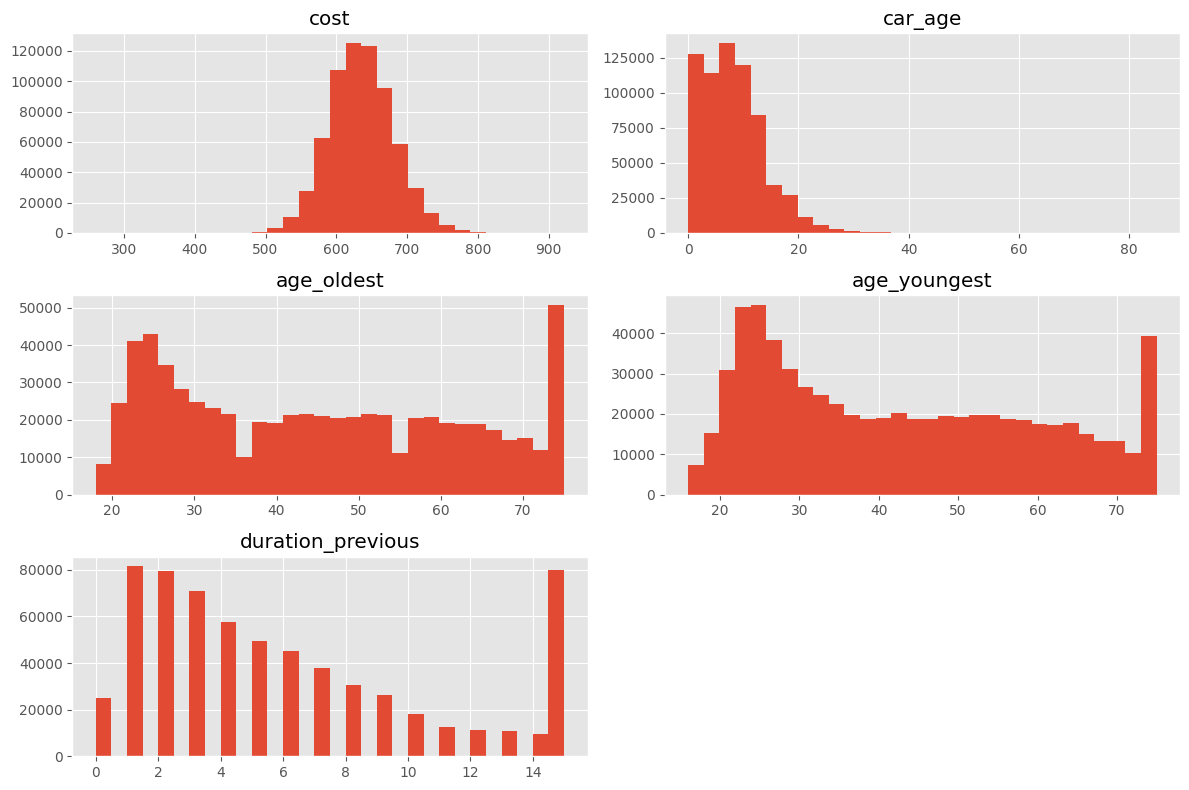

In [20]:
num_cols = ["cost", "car_age", "age_oldest", "age_youngest", "duration_previous"]
df[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

### Observation

- `cost`: Displays a relatively normal distribution centered around 600-650.
- `car_age`: Highly leftt-skewed, showing that most customers own newer or moderately aged cars, with very few old vehicles.
- `age_oldest` and `age_youngest`: Show distinct patterns representing demographic structures (e.g., younger vs older drivers in a household).

### Şərh / Müşahidə

- `cost`: 600-650 ətrafında mərkəzləşmiş nisbətən normal bir paylanma nümayiş etdirir.
- `car_age`: Güclü şəkildə sola meyllidir (left-skewed), bu da əksər müştərilərin yeni və ya orta yaşlı avtomobillərə sahib olduğunu, köhnə nəqliyyat vasitələrinin isə çox az olduğunu göstərir.
- `age_oldest` və `age_youngest`: Ailədəki sürücülərin yaş strukturunu (məsələn, gənc və yaşlı sürücülərin birgə olması) ifadə edən fərqli qanunauyğunluqlar göstərir.

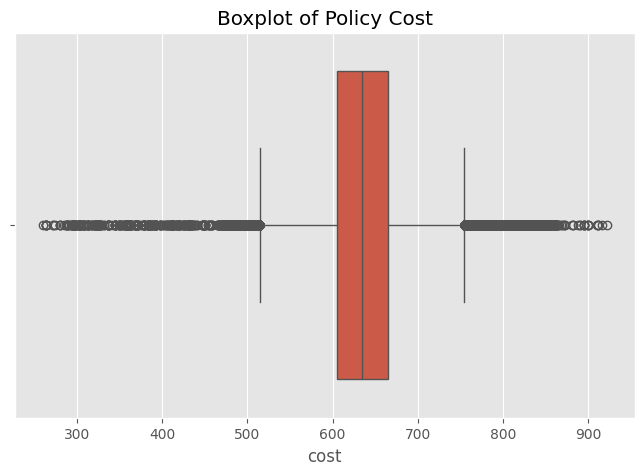

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["cost"])
plt.title("Boxplot of Policy Cost")
plt.show()

### Observation

The boxplot for `cost` reveals potential outliers on both ends (extremely cheap or expensive policy quotes). We must keep this in mind during feature engineering. Tree-based models (XGBoost, CatBoost) handle outliers well, but they might still influence our aggregated history statistics (like mean or max cost).

### Şərh / Müşahidə

`cost` (qiymət) üçün çəkilmiş boxplot qrafiki hər iki tərəfdə potensial kənar göstəriciləri (outliers - həddindən artıq ucuz və ya baha təkliflər) üzə çıxarır. Feature engineering mərhələsində bunu nəzərə almalıyıq. Ağac əsaslı modellər (XGBoost, CatBoost) kənar göstəricilərə qarşı davamlı olsalar da, bu dəyərlər tarixdən çıxaracağımız aqreqat statistikalarına (orta və ya maksimum qiymət kimi) təsir göstərə bilər.